FEUILLE DE TP 11

# Introduction aux schémas numériques pour f(x) = 0 
## (Apprentissage du cours)

---
**Remarques:**
>* L' **Exercice 1** a déjà été traité dans la fiche **TP03** (il n'est introduit ici que pour être consistant avec le support du cours). 
>* L' **Exercice 5** est facultatif.
---

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt

## Exercice 1 :  Ordre de convergence des suites


### Question 1.1:

> Fournir une fonction `TraquerOrdre(xn, lim = 0.0, ax = None, title=''))`
qui calcul l'ordre de convergence de la suite `xn`


In [24]:
## METTRE LE CODE ICI
def TraquerOrdre(xn, lim = 0.0, ax = None, title=''):
    '''
    Fonction qui calcule l'ordre de convergence de la suite
    passée en argument
    ENTREE:
      xn    -> tableau des éléments de la suite
      lim   -> limite de la suite
      ax    -> est la fenêtre graphique sur laquelle le dessin s'effectue
      title -> le titre à associer
    SORTIE:
       - ordre de la suite
       - graphique qui trace à l'echelle log 
           - la courbe log(|x_n - lim|) -> log(|x_{n+1} - lim|)
           - la courbe de regression linéaire associée
    '''
    #COMPLETER
    # Trancer la courbe log(|x_n - lim|) -> log(|x_{n+1} - lim|) en pointillés   
    e = np.log(np.abs(xn - lim))
    ex, ey = e[0:-1], e[1:]
    ax.plot(ex, ey, '+', label='nuages')    
    # Estimer l' ordre q de convergence de la suite (utiliser une des approches vues en cours)
    a, b = np.polyfit(ex, ey,1)
    # Représenter sur le même graphique la courbe de pente q (ici q est réel et non entier) en ligne continue
    ax.plot(ex, b + a * ex, label=f"$x \mapsto {b:3.2f} + {a:3.2f}\, x$")
    # Mettre les légendes 
    ax.legend()
    # Mettre le titre il doit contenir l'information sur l'ordre de convergence estimé 
    ax.set_title(title + f" convergence d'ordre :{a:3.2f}")
    # Décoration des axes
    ax.set_xlabel(f"$\log(|e_n|)$")
    ax.set_ylabel(f"$\log(|e_{{n+1}}|)$")
    

#### Question 1.2
> Tester votre algorithme en calculant, si elle converge, **l'ordre** de convergence de chacune des suites suivantes
  $$ u_n = (0.08)^n, \qquad v_n = (0.99)^n  \qquad  w_n  = (0.8)^{2^n}$$
 > On calculera et affichera les 30 premiers termes de ces suites. On pourra aussi représenter graphiquement les droites de pente 1, 2, 3 passant par un point bien choisi.
 
 

/tmp/ipykernel_4415/3160609542.py:19: RuntimeWarning: divide by zero encountered in log
  e = np.log(np.abs(xn - lim))
/usr/lib/python3/dist-packages/numpy/lib/polynomial.py:659: RuntimeWarning: invalid value encountered in true_divide
  lhs /= scale


ValueError: On entry to DLASCL parameter number 4 had an illegal value

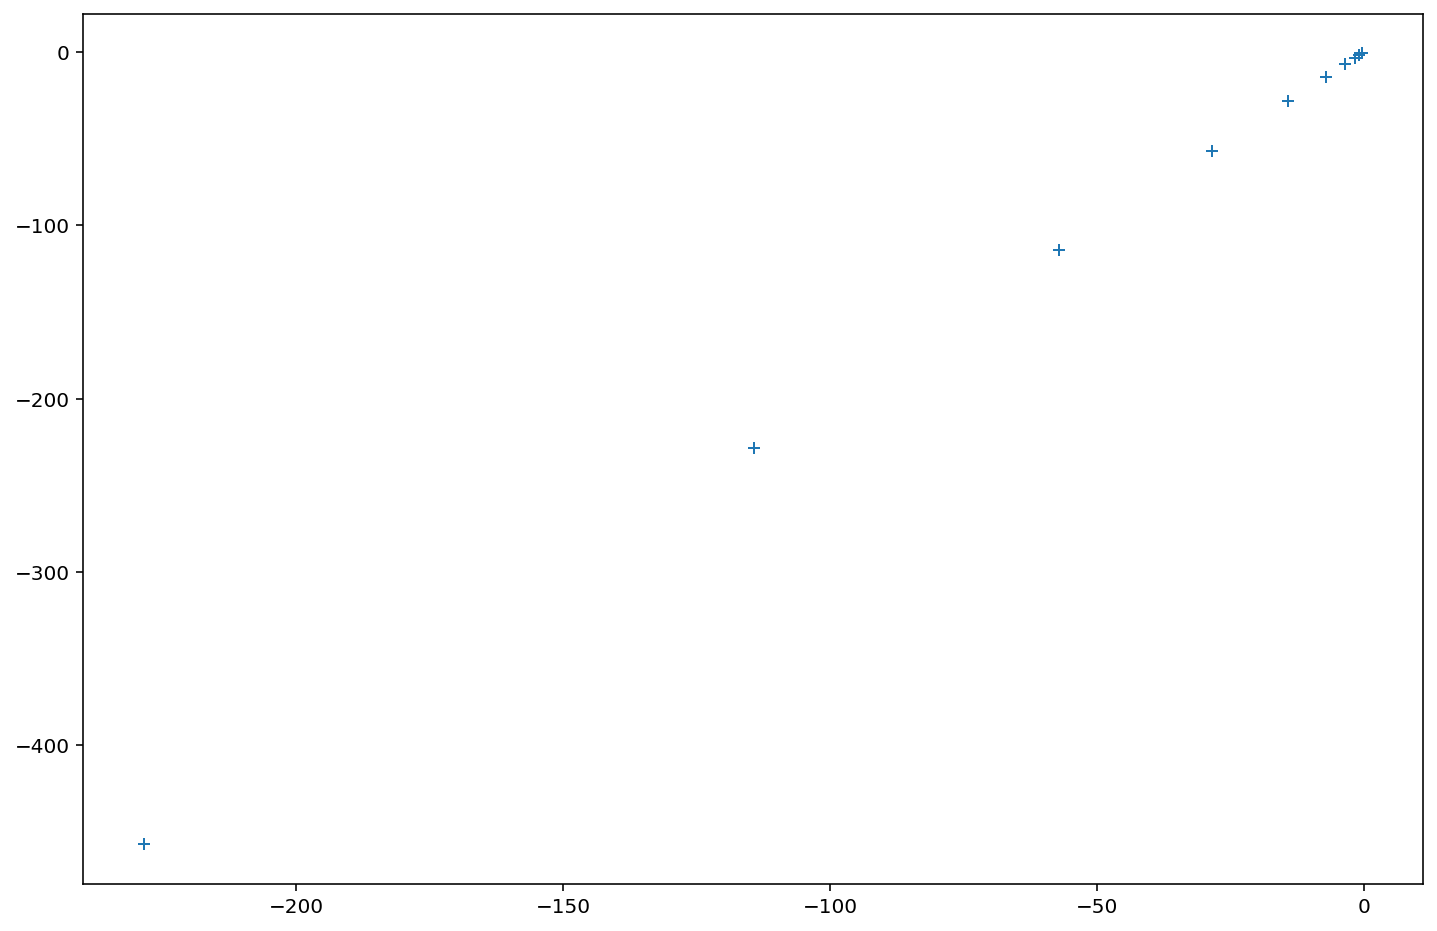

In [27]:
def un(n):
    return np.power(0.08,n)

def vn(n):
    return np.power(0.99,n)

def wn(n):
    return 0.8**(2**n)


n = np.arange(1, 30)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
TraquerOrdre(wn(n), 0, ax, 'un')

#### Question 1.3  Termes ajoutés par itération

> 
* Calculer à la main les **constantes asymptotiques** des suites données ci-dessus
* Montrer et vérifier numériquement qu'à chaque itération  
    * avec la suite $v_n$ il faut **230** itérations pour gagner une décimale
    * avec la suite $u_n$ on gagne **une** décimale à chaque itération


Pour une suite géométrique, $s_n = r^n$, nous avons
$$ s_{n+p} = r^{n+p} = s_n s_p.$$
Ainsi, pour avoir $s_{n+p} \leq s_n/10$, il faut exactement $p$ tel que $r^p\geq .1$, soit

In [31]:
# METTRE LE CODE ICI
# nombre de termes à calculer pour diviser par 10 la suite $u_n$
n = np.arange(1, 300)
for i in n:
    if np.abs(un(i)) < 0.1:
        print(f"u({i}) = {un(i)}")
        break


# nombre de termes à calculer pour diviser par 10 la suite $v_n$

n = np.arange(1, 300)
for i in n:
    if np.abs(vn(i)) < 0.1:
        print(f"u({i}) = {un(i)}")
        break


u(1) = 0.08
u(230) = 5.136851466355858e-253


Pour la suite $w_n=r^{2^n}$, nous avons 
$$w_{n+1} = (r^{2^n})^2.$$
Ainsi, à chaque itération, le nombre de décimales correctes est doublé.

## Exercice 2 : Méthode de  dichotomique

Pour cet exercice on fera les tests avec les fonctions suivnates
> * a) $\quad f(x) = e^{x} - 1 - 0.5 x - 0.5 x^2 \quad \text{sur} \quad   [-1, 2]$
> * b) $\quad f(x) = e^{x} - 1 - x \quad \text{sur} \quad   [-1, 2]$
> * c) $\quad f(x) = e^{x} - 1 - x - 0.5 x^2 \quad \text{sur} \quad   [-1, 2]$

Commencez par implémenter ces 3 fonctions.

In [79]:
def f1(x):
    return np.exp(x)-1-0.5*x -0.5*x**2
def f2(x):
    return np.exp(x)-1-x
def f3(x):
    return np.exp(x)-1-x-0.5*x**2

### Question 2.1  Préparation

> Implémenter la méthode de Dichotomie à travers une fonction `x, niter, aL, bL = Dichotomie(f, a, b, tol, iterMax)` qui prend en arguments
>  * la fonction $f$ dont on cherche la racine, 
>  * l'intervalle $[a, b]$ avec $f(a) f(b) < 0$, 
>  * le paramètre $tol$ du test d'arrêt : on arrête si $|f(x)| < tol$
>  * et le nombre $iterMax$ maximum d'itérations autorisées.
>
> et qui retourne : 
> * $x$ la solution approchée, 
> * $niter$ le nombre d'itérations réalisées, 
> * $aL$  (respectivement $bL$) la liste des extrémités gauches (respectivement droites) des intervalles par itération.




In [80]:
## METTRE LE CODE ICI

def Dichotomie(f, a, b,  tol = 1e-6, iterMax = 500):
      '''
      Approximation du zeros d'une fonction f passée en argument
      ENTREES:
            f       -> la fonction
            a, b    -> intervalle [a,b] avec f(a) f(b) < 0
            tol     -> paramètre du test d'arrêt : arrêt si |f(x)| < tol ou si longueur de l'intervalle < tol
            iterMax -> nombre maximal uatorisé d'itérations 
      SORTIES:
            x        -> la solution approchée
            niter    -> nombre d'itérations effectuées
            aL, bL   -> liste des extrémité des intervalles générés par itérations
                        aL[n] est l'extrémité gauche de l'intervalle à l'itération n
                        bL[n] est l'extrémité droite de l'intervalle à l'itération n
      '''
      al = []
      bl = []
      al.append(a)
      bl.append(b)
      x = (a+b)/2
      while iterMax > 0:
            if f(x) == 0:
                  return x, iterMax, al, bl
            elif f(x) < 0:
                  a = x
            else:
                  b = x
            iterMax -= 1
            al.append(a)
            bl.append(b)
            x = (a+b)/2

      return x, iterMax, al,bl


### Question 2.2  Analyse

#### Question 2.2.1 Compréhension de la méthode

> Pour le cas a), b), c) ci-dessus, 
>  * Tracer sur un graphique la fonction $f$ et la droite $y = 0$ et conclure que f admet bien une solution.
>  * Calculer la solution approchée $x^*$  et la représenter sur le même graphique. 
>
> * Représenter sur une autre figure l'évolution des segments $[a_n, b_n]$ en représentant les segments de droites joignant les points $(a_n, n), (b_n, n), n=0,\ldots$
> * Représenter aussi la ligne brisée joignant les points $(a_n,n),(a_{n+1},n+1), n=0\ldots$ ainsi que la ligne brisée $(b_n,n),(b_{n+1},n+1), n=0\ldots$.
> *  Que remarquez-vous ?

On prendra les paramètres ` tol = 1e-6 iterMax = 5000 `.

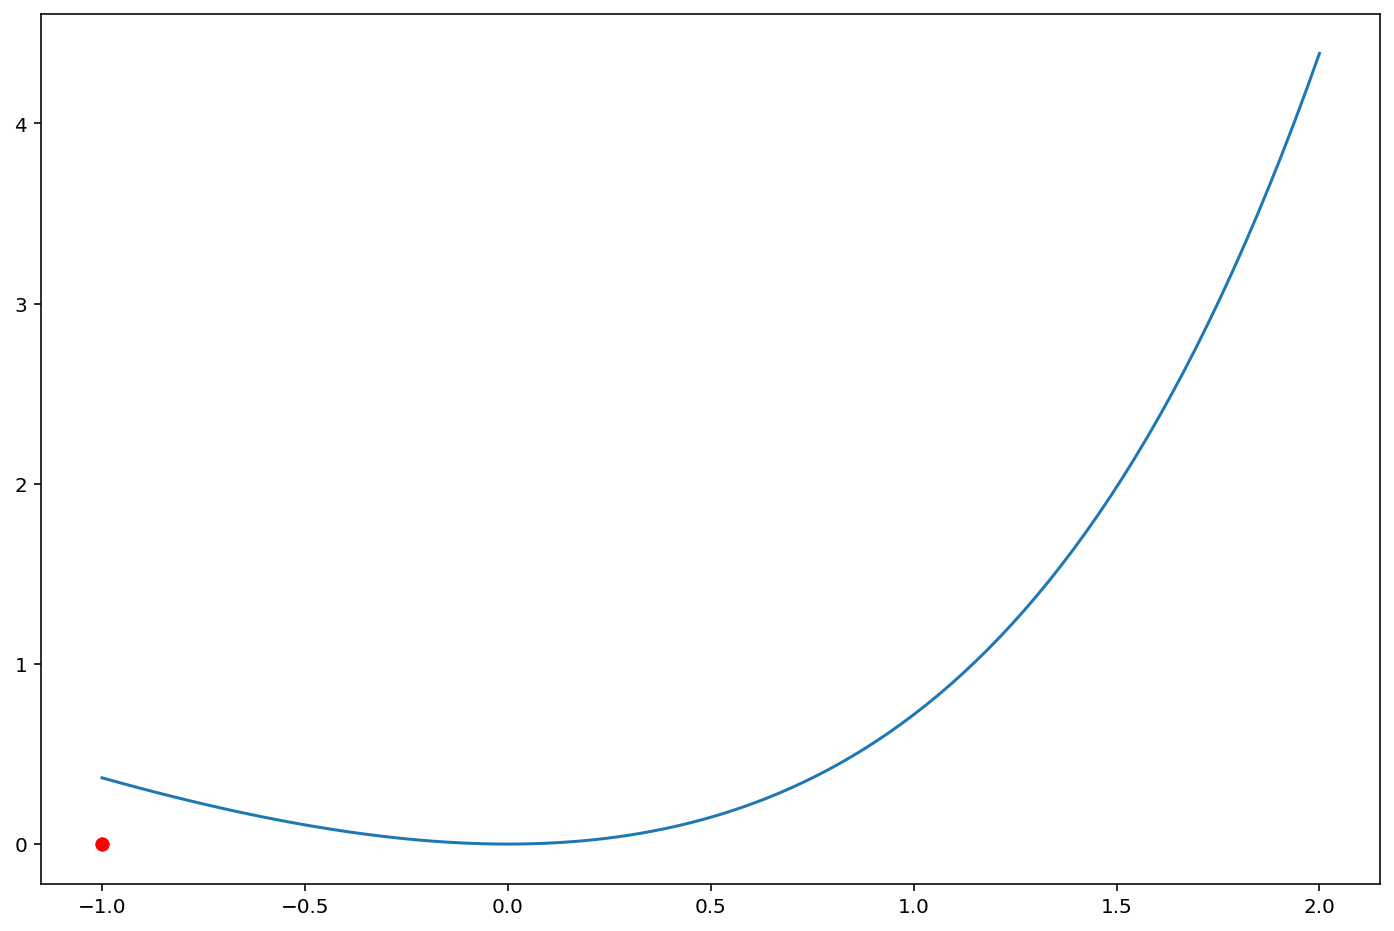

In [86]:
## METTRE LE CODE ICI
f = [f2]
tol = 1.e-6
iterMax = 5000
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
x_vals = np.linspace(-1, 2, 100)
for func in f:
    ax.plot(x_vals, func(x_vals), label=f"$f(x) = {func.__name__}$")
    a, b = -1, 2
    x_approx, niter, aL, bL = Dichotomie(func, a, b, tol, iterMax)
    ax.plot([aL[-1], bL[-1]], [0, 0], 'ro', label='solution approchée')


#### Question 2.2.2 Convergence de la méthode

> En utilisant la fonction `TraquerOrdre` et le cas test **a)**,
> * Estimer l'ordre de convergence des $a_n$, $b_n$ ver la racine $x^* =  0$ de $f$. 
> * Estimer l'ordre de convergence des longueurs des intervalles  ($|b_n - a_n|$) vers 0.
> * En utilisant un résultat du cours, estimer à l'avance le nombre d'itérations nécessaires dans le cas test ci-dessus. Comparer ce nombre à celui obtenu pendant le test.

In [7]:
## METTRE LE CODE ICI 
 

## Exercice 3 : Méthode de fausse position

Pour cet exercice on fera les tests avec les fonctions suivantes
> * a) $\quad f(x) = e^{x} - 1  \quad \text{sur} \quad   [-1, 1]$
> * b) $\quad f(x) = e^{-x} - 1 \quad \text{sur} \quad   [-1, 1]$
> * c) $\quad f(x) = -e^{x} + 1 \quad \text{sur} \quad   [-1, 1]$
> * d) $\quad f(x) = -e^{-x} + 1 \quad \text{sur} \quad  [-1, 1]$


### Question 3.1 : Préparation
> Implémenter la méthode de fausse position à travers une fonction `x, niter, aL, bL = FaussePosition(f, a, b, tol, iterMax)`.
La nature des arguments sont comme décrits dans la méthode de Dichotomie ci-dessus.

In [8]:
## METTRE lE CODE ICI

def FaussePosition(f, a, b, tol = 1e-6, iterMax = 5000):
    ''' 
    Approximation du zeros d'une fonction f passée en argument
    ENTREES:
          f       -> la fonction
          a, b    -> intervalle [a,b] avec f(a) f(b) < 0
          tol     -> paramètre du test d'arrêt : arrêt si |f(x)| < tol ou si longueur de l'intervalle < tol
          iterMax -> nombre maximal uatorisé d'itérations 
    SORTIES:
         x        -> la solution approchée
         niter    -> nombre d'itérations effectuées
         aL, bL   -> liste des extrémité des intervalles générés par itérations
                    aL[n] est l'extrémité gauche de l'intervalle à l'itération n
                    bL[n] est l'extrémité droite de l'intervalle à l'itération n

    '''
    #COMPLETER


### Quesrion 3.2  Analyse de la méthode

#### Question 3.2.1 Compréhension de la méthode

> * Pour les différents cas tests ci-dessus, reprendre l'expérience de la **question 2.2.1**
> * Sur le même graphique représenter sur l'axe des abscisses les 4 premiers itérés $a_0,  a_1,  a_2$ et $b_0,  b_1,  b_2$ 
et pour pour i = 0, 1, 2
>   * les points $(a_i, f(a_i))$, $(b_i, f(b_i))$,
>   * la droite joignant les points $(a_i, f(a_i))$ et $(b_{i}, f(b_{i}))$

*Remarquer dans chaque cas, que comme dans la méthode de dichotomie, les intervalles $[a_n,b_n]$ sont **emboîtés**. 
Mais contrairement à la méthode de dichotomie l'une des extrémités de l'intervalle reste fixe: c'est-à-dire que **l'une des suites $a_n$ ou $b_n$ est stationnaire**.*


In [9]:
## METTRE LE CODE ICI

tol = 1.e-6
iterMax = 5000


#### Question 3.2.2 Convergence de la méthode

>* En remarquant que $f$ dans chacun des cas ci-dessus est soit **convexe** soit **concave**, en évaluant les signes de $f(a)$ et $f(b)$, essayer d'identifier les configurations dans la méthode de fausse position où c'est la suite des extrémités gauches qui reste constante. Faites de même pour la suite des extrêmités de droites.

>* En utilisant la fonction `TraquerOrdre` et les cas test **a)**. Determiner l'ordre de convergence de la suite $a_n$ ou 
$b_n$ vers la racine $x^* = 0$ de $f$.


In [10]:
## METTRE LE CODE ICI


### Question 3.3 Comparaison 
> On pourra dans cette question se contenter de comparer le nombre d'itérations.
> * Pour le cas test   $\quad f(x) = e^{x} - 1 - x - 0.5x^2 \quad \text{sur} \quad  [-0.9, 1]$
> * Comparer la méthode de **dichotomie** et celle de la **fausse Position**.
> * Que remarquez-vous ?
> * Reprendre dans le cas $\quad f(x) = e^{x} - 1 - 0.5 x - 0.5x^2 \quad \text{sur} \quad  [-0.9, 1]$

In [11]:
## METTRE LE CODE ICI


## Exercice 3 : Méthode d'itération (ou de point fixe)

Dans cette exercice, on va utiliser les fonctions et les données initiales $x_0$ correspondantes 

> * a) $\quad f(x) =  e^{x} - 1 - x - 0.5x^2  \quad \text{sur} \quad   [-1, 1],  \quad  x_0 = -0.5$ 
> * b) $\quad f(x) =  x - \sin(x) \quad \text{sur} \quad   [-\frac{\pi}{2}, \frac{5\pi}{2}],  \quad  x_0 = 1$ 
> * c) $\quad f(x) =  x + \sin(x) \quad \text{sur} \quad   [-\frac{\pi}{2}, \frac{5\pi}{2}],  \quad  x_0 = 1$ 
> * d) $\quad f(x) =  x + \cos(x) -1 \quad \text{sur} \quad   [-\frac{\pi}{2}, \frac{5\pi}{2}],  \quad  x_0 = 1$ 
> * e) $\quad f(x) =  x - \cos(x) +1 \quad \text{sur} \quad   [-\frac{\pi}{2}, \frac{5\pi}{2}],  \quad  x_0 = 1$ 

**Remarque**: 
>* Dans a) on cherche la racine de $e^{x} - 1 - 2 x - 0.5 x^2 = 0$.
>* Dans les cas tests b), c), d), e), on cherche la racine simple $x^* = 0$ de $\sin(x) = 0$. 

### Question 3.1 Préparation

> Implémenter la méthode du point fixe à travers une fonction `x, niter, xL = PointFixe(f, x0, tol, iterMax)`


In [12]:
## METTRE LE CODE ICI


### Question 3.2 Analyse

#### Question 3.2.1 Compréhension de la méthode 

> Pour chacun des cas tests ci-dessus faire
>   * Tracer dans un même graphique la courbe de la fonction $f$ et celle de la droite $x \mapsto x$. 
Et conclure que $f$ admet un unique point fixe dans l'intervalle $[a,b]$ considéré.
>   * Générer la suite des itérés $x_n$ de la méthode d'itération du point fixe. 
>   * Représenter sur le même graphique la solution numérique  $x^*$ si elle existe: 
en dessinant un point à la position $(x^*, f(x^*))$ 
>   * Représenter la ligne brisée joignant les points $(x_n, f(x_n)), (x_{n+1}, x_{n+1}), n=0,\ldots, $
>   * Que remarquez-vous ?

In [13]:
## METTRE LE CODE ICI

tol = 1.e-6
iterMax = 5000


#### Question 3.2.2 Convergence de la méthode 

> Pour chacun des cas tests ci-dessus faire
> * si la méthode converge, 
>    * calculer la vitesse de convergence de la suite *(On pourra utiliser la fonction **TraquerOrdre** ci-dessus)*
>    * calculer la constante asymptotique de convergence de la méthode  
>    * estimer donner le nombre d'itérations nécessaires pour gangner un chiffre exacte et vérifier que c'est le cas effectivement.
> * Calculer eventuellement $f^{'}(x^*), f^{''}(x^*), f^{'''}(x^*) $ où $x^*$ est le point fixe de $f$ vers lequel la méthode semble converger et justifier le comportement de la suite générée à la lueur de ces valeurs.

## Exercice 4 : Méthode de Newton

Dans cette exercice, on va utiliser les fonctions et les données initiales $x_0$ correspondantes 

> * a) $\quad f(x) =  e^x - 1 \quad \text{sur} \quad   [-1, 1],  \quad  x_0 = -0.5$ 
> * b) $\quad f(x) = e^{x} - 1 - x - 0.5 x^2 \quad \text{sur} \quad   [-1, 1],  \quad  x_0 =-0.5$
> * c) $\quad f(x) = e^{x} - 1 - 0.5 x - 0.5 x^2 \quad \text{sur} \quad   [-1, 1],  \quad  x_0 =-0.5$

### Question 4.1 Préparation

> Implémenter la méthode de Newton à travers une fonction ** x, niter, xL = Newton(f, fprime, x0, tol, iterMax)**

> Les paramètres en entrées et de sorties sont comme dans la méthode du point fixe, avec la seule donnée suplémentaire, 
la fonction **fprime** qui représente la dérivée de **f**

> * On peut même montrer que son implémentation peut se faire usage de la fonction **PointFixe**..


In [14]:
def Newton(f, fprime, x0, tol, iterMax):
    '''
    DOCUMENTATION ICI
    '''
    # COMPLETER


### Question 4.2  Analyse

Dans les questions qui suivent pour utiliser les cas tests ci-dessus, il faudra fournir la fonction dérivée de $f$.

#### Question 4.2.1 Compréhension de la méthode

> Pour le cas a) 
 * Tracer sur un graphique la fonction $f$ et la droite $y = 0$ et conclure que f admet bien une solution
 * Calculée la solution approchée $x^*$  et la représenter sur le même graphique
 * Sur le même graphique représenter sur l'axe des abscisses les 4 premiers itérés $x_0,  x_1,  x_2,  x_3$ et pour i = 0, 1, 2
   * le point $(x_i, f(x_i))$,
   * la tangente à la courbe de $f$ passant par le point $(x_i, f(x_i))$
 *  Que remarquez-vous ?



#### Question 4.2.2 Convergence de la méthode
 >* En utilisant la fonction **TraquerOrdre**
  >* Estimer l'ordre de convergence de la méthode dans le cas **a)**.
  >* Estimer l'ordre de convergence dans le cas **b)**. A-t-on l'ordre 2 ici ? Pouvez-vous expliquer pourquoi?


#### Question 4.2.3 Convergence de la méthode: cas des racines d'ordre de multiplicité m > 1

>* Vérifier à la main l'ordre de multiplicite $m$ de la racine $x^* = $ de $f$ dans le cas **b)**
* Reprendre l'estimation de l'ordre de convergence de la suite générée dans le cas **b)**  l'orsqu'on remplace 
  * l'appel  ``` Newton(f, fp, tol, iterMax) ``` par ``` Newton(lambda x: m * f(x), fp, tol, iterMax) ``` où $m$ est l'ordre de multiplicité de la racine obtenue ci-dessus. 
  * Pouvez-vous expliquer la correction que l'on a apprortée à la méthode de Newton ? 
* Pouvez-vous fournir une formule qui estime numériquement l'ordre de multiplicité $m$ de la racine $x^*$ à l'aide de la suite générée par la méthode de Newton non modifiée ?
 

## Exercice 5 : Méthode de la sécante ( Exercice Facultatif)

Dans cette exercice, on va utiliser les fonctions et les données initiales $x_0, x_1$ correspondantes

> * a) $\quad f(x) = e^{x} - 1 \quad \text{sur} \quad   [-1, 1],  \quad  x_0 =-0.5, \quad  x_1 = 1$
> * b) $\quad f(x) = e^{x} - 1 - x  \quad \text{sur} \quad   [-1, 1],  \quad  x_0 =-0.5, \quad  x_1 = 1$
> * c) $\quad f(x) = e^{x} - 1 - x - 0.5 x^2 \quad \text{sur} \quad   [-1, 1],  \quad  x_0 =-0.5, \quad  x_1 = 1$
> * d) $\quad f(x) = e^{x} - 1 - 0.5 x - 0.5 x^2 \quad \text{sur} \quad   [-1, 1],  \quad  x_0 =-0.5, \quad  x_1 = 1$


### Question 5.1 Préparation

> Implémenter la méthode de Sécante à travers une fonction `x, niter, xL = Secante(f, x0, x1, tol, iterMax)`

> * Les parmètres de sorties ainsi que les paramètres d'entréess `f, x0, tol, iterMax` sont comme dans la méthode de Newton. 
Mais cette fois-ci on a besoin d'une approximation initiale supplémentaire, d'où la présence de `x1`

> * On pourra remarquer que la méthode de Sécante consiste à remplacer dans laméthode de Newton, la dérivée $ f^{'}(x_n)$ par 
la défférence divisée $\frac{f(x_n) - f(x_{n-1})}{x_n - x_{n-1}}$. D'où la nécessiter de disposer de deux approximations initiales.



In [15]:
## METTRE LE CODE ICI
def Secante(f, x0, x1, tol, iterMax, m =1):  # Pour l'importante de m = 1 voir question 5.2.3 ci-dessous
    '''
      DOCUMENTATION ICI
    '''
    ##COMPLETER


### Question 5.2  Analyse

### Question 5.2.1 Compréhension de la méthode

>Pour le cas a) 
 * Tracer sur un graphique la fonction $f$ et la droite $y = 0$ et conclure que f admet bien une solution
 * Calculer la solution approchée $x^*$  et la représenter sur le même graphique
 * Sur le même graphique représenter sur l'axe des abscisses les 4 premiers itérés $x_0,  x_1,  x_2,  x_3$ et pour i = 0, 1, 2
   * le point $(x_i, f(x_i))$,
   * la droite joignant les points $(x_i, f(x_i))$ et $(x_{i+1}, f(x_{i+1}))$
 *  Que remarquez-vous ?



#### Question 5.2.2 Convergence de la méthode
 > En utilisant la fonction **TraquerOrdre**
  >* Estimer l'ordre de convergence de la méthode dans le cas **a)**. Comparer cette valeur au nombre **d'or** $\frac{1+ \sqrt{5}}{2}$.
  >* Estimer l'ordre de convergence dans le cas **b)**.
   >>* A-t-on la même valeur que dans le cas **a)** ?
   >>* Estimer la constante asymptotique de l'erreur $\displaystyle K_b = \lim_{n \rightarrow \infty} \frac{x^* - x_{n+1}}{x^* - x_{n}}$.
  >* Estimer l'ordre de convergence dans le cas **c)**. 
   >>* A-t-on la même valeur que dans le cas **a)**, que dans le cas **b)**?
   >>* Estimer la constante asymptotique $\displaystyle  K_c = \lim_{n \rightarrow \infty} \frac{x^* - x_{n+1}}{x^* - x_{n}}$.
  


#### Question 5.2.3 Convergence de la méthode: cas des racines d'ordre de multiplicité m > 1

 >* Déterminer à la main l'ordre de multiplicite $mb$ de la racine $x^* = 0$ de $f$ dans le cas **b)**
  >>* Verifier que $K_b$ trouvé ci-dessus est racine de $K^{mb} + K^{mb - 1} - 1 = 0\,$  située dans $[(\frac{1}{2})^{\frac{1}{mb}},  (\frac{1}{2})^{\frac{1}{mb-1}}]$
  >>* Améliorer alors la valeur de $K_b$  en résolvant cette équation numériquement si nécessaire par exemple par la méthode de Newton.
 
 >* Déterminer à la main l'ordre de multiplicite $mc$ de la racine $x^* = $ de $f$ dans le cas **c)**
 >>* Verifier que $K_c$ trouvé ci-dessus est racine de $K^{mc} + K^{mc - 1} - 1 = 0\,$  située dans $[(\frac{1}{2})^{\frac{1}{mc}},  (\frac{1}{2})^{\frac{1}{mc-1}}]$
 >>* Améliorer la valeur de $K_c$. 
 
 >* Modifier la méthode de sécante en remplaçant le calcul 
 >> - $\displaystyle x_{n+1} = x_{n}  - \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})} f(x_n)$ par 
 >> - $\displaystyle  x_{n+1} = x_{n}  - m \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})} f(x_n)$ où $m$ est l'estimation de l'ordre de multiplicité  de la racine de $f$ cherchée.
 >> - *Remarquer que cela revient à fournir une fonction **x, niter, xL = Secante(f,x, x0, x1, tol, iterMax, m = 1)**   
 C'est-à-dire à passer l'ordre de multiplicité en dernier argument et en lui affectant la valeur 1 par defaut.*


 
>*  Reprendre l'estimation de l'ordre de convergence de la méthode Sécante dans les cas **b)** et **c)** lorsqu'on prend en compte les ordres de multiplicité **mb** et **mc**. 

>* Que constatez-vous ?
 